In [1]:
import datetime
import numpy as np
import pandas as pd
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import LSTM
from tensorflow.keras.optimizers import Adam

In [2]:
def load_data(battery):
  mat = loadmat('../datasets/battery_data/' + battery + '.mat')
  print('Total data in dataset: ', len(mat[battery][0, 0]['cycle'][0]))
  counter = 0
  dataset = []
  capacity_data = []
  
  for i in range(len(mat[battery][0, 0]['cycle'][0])):
    row = mat[battery][0, 0]['cycle'][0, i]
    if row['type'][0] == 'discharge':
      ambient_temperature = float(row['ambient_temperature'][0][0][0,0])
      date_time = datetime.datetime(int(row['time'][0][0][0,0]),
                               int(row['time'][0][0][0,1]),
                               int(row['time'][0][0][0,2]),
                               int(row['time'][0][0][0,3]),
                               int(row['time'][0][0][0,4])) + datetime.timedelta(seconds=int(row['time'][0][0][0,5]))
      data = row['data']
      capacity = float(data[0][0]['Capacity'][0][0][0,0])
      for j in range(len(data[0][0]['Voltage_measured'][0])):
        voltage_measured = data[0][0]['Voltage_measured'][0][j]
        current_measured = data[0][0]['Current_measured'][0][j]
        temperature_measured = data[0][0]['Temperature_measured'][0][j]
        current_load = data[0][0]['Current_load'][0][j]
        voltage_load = data[0][0]['Voltage_load'][0][j]
        time = data[0][0]['Time'][0][j]
        dataset.append([counter + 1, ambient_temperature, date_time, capacity,
                        voltage_measured, current_measured,
                        temperature_measured, current_load,
                        voltage_load, time])
      capacity_data.append([counter + 1, ambient_temperature, date_time, capacity])
      counter = counter + 1
  print(dataset[0])
  return [pd.DataFrame(data=dataset,
                       columns=['cycle', 'ambient_temperature', 'datetime',
                                'capacity', 'voltage_measured',
                                'current_measured', 'temperature_measured',
                                'current_load', 'voltage_load', 'time']),
          pd.DataFrame(data=capacity_data,
                       columns=['cycle', 'ambient_temperature', 'datetime',
                                'capacity'])]
dataset, capacity = load_data('B0005')
pd.set_option('display.max_columns', 10)
print(dataset.head())
dataset.describe()

Total data in dataset:  168
[1, 24.0, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.8564874208181574, array([[4.19149181, 4.19074907, 3.97487091, 3.95171671, 3.93435249,
        3.92005844, 3.90790351, 3.89703572, 3.88747658, 3.87895859,
        3.87101598, 3.86347968, 3.85666051, 3.85001358, 3.84384191,
        3.83768798, 3.83193825, 3.82641444, 3.82109573, 3.81589666,
        3.81069682, 3.80583738, 3.80112163, 3.79629313, 3.79144891,
        3.78662469, 3.78206292, 3.7771754 , 3.77240629, 3.76793746,
        3.7632293 , 3.75851149, 3.75421321, 3.7496292 , 3.74516886,
        3.74100501, 3.73669983, 3.73248271, 3.72835255, 3.72453324,
        3.72065103, 3.71640901, 3.71279184, 3.70842761, 3.70479177,
        3.70068258, 3.69675771, 3.69303933, 3.6891768 , 3.68521448,
        3.68149374, 3.67779221, 3.67406181, 3.67030176, 3.66673391,
        3.66299805, 3.65966439, 3.65589414, 3.65232651, 3.64876348,
        3.64554686, 3.64207625, 3.63846406, 3.63507607, 3.63166482,
        3.62857

,cycle,ambient_temperature,datetime,capacity
count,168.000000,168.0,168,168.000000
mean,84.500000,24.0,2008-05-05 12:23:59.065476,1.572502
min,1.000000,24.0,2008-04-02 15:25:41,1.287453
25%,42.750000,24.0,2008-04-25 08:27:20.750000,1.390021
50%,84.500000,24.0,2008-05-07 04:40:43.500000,1.557085
75%,126.250000,24.0,2008-05-17 23:24:28,1.769163
max,168.000000,24.0,2008-05-27 20:45:42,1.856487
std,48.641546,0.0,NaN,0.190413


In [3]:
dataset

,cycle,ambient_temperature,datetime,capacity,voltage_measured,current_measured,temperature_measured,current_load,voltage_load,time
0,1,24.0,2008-04-02 15:25:41,1.856487,"[[4.191491807505295, 4.190749067776103, 3.9748...","[[-0.0049015892074626, -0.0014780055516425, -2...","[[24.330033885570543, 24.325993424022467, 24.3...","[[-0.0006, -0.0006, -1.9982, -1.9982, -1.9982,...","[[0.0, 4.206, 3.062, 3.03, 3.011, 2.991, 2.977...","[[0.0, 16.781, 35.703, 53.781, 71.922, 90.094,..."
1,2,24.0,2008-04-02 19:43:48,1.846327,"[[4.189773213846608, 4.188881380279099, 3.9791...","[[2.125117981080765e-05, -0.0008794712663407, ...","[[24.697751935729325, 24.685948163596, 24.7381...","[[-0.0006, -0.0006, -1.9984, -1.9982, -1.9984,...","[[0.0, 4.204, 3.056, 3.024, 3.003, 2.983, 2.97...","[[0.0, 16.672, 35.703, 53.828, 71.891, 90.047,..."
2,3,24.0,2008-04-03 00:01:06,1.835349,"[[4.188186735991303, 4.187198338393574, 3.9799...","[[-0.0017540301662326, -0.0017916477486935, -2...","[[24.7342661639544, 24.74050014862512, 24.7914...","[[-0.0006, -0.0006, -1.9982, -1.9982, -1.9982,...","[[0.0, 4.203, 3.055, 3.023, 3.0, 2.981, 2.97, ...","[[0.0, 16.796999999999997, 35.766, 53.891, 72...."
3,4,24.0,2008-04-03 04:16:37,1.835263,"[[4.188461118855572, 4.187752210174129, 3.9816...","[[-0.0027750361294468, 0.0002337127076932, -2....","[[24.65423646922845, 24.65224374129252, 24.697...","[[-0.0006, -0.0006, -1.9982, -1.9982, -1.9982,...","[[0.0, 4.203, 3.055, 3.023, 2.999, 2.982, 2.97...","[[0.0, 16.766000000000002, 35.75, 53.813, 72.0..."
4,5,24.0,2008-04-03 08:33:25,1.834646,"[[4.188298524761055, 4.187384730878918, 3.9822...","[[-0.0079808668038886, 0.0017014548245034, -2....","[[24.524796959348127, 24.518700434435164, 24.5...","[[-0.0006, -0.0006, -1.9982, -1.9982, -1.9982,...","[[0.0, 4.203, 3.056, 3.025, 3.0, 2.984, 2.973,...","[[0.0, 16.719, 35.656000000000006, 53.859, 72...."
...,...,...,...,...,...,...,...,...,...,...
163,164,24.0,2008-05-26 10:44:38,1.293464,"[[4.196640912532072, 4.195891409328115, 3.9704...","[[-0.0031723450500138, -0.0011655481139208, -2...","[[23.74142414166957, 23.73611267134457, 23.762...","[[0.0006, 0.0006, 1.998, 1.9982, 1.998, 1.9982...","[[0.0, 4.211, 2.944, 2.931, 2.92, 2.906, 2.894...","[[0.0, 9.343, 19.484, 28.765000000000004, 38.0..."
164,165,24.0,2008-05-26 15:30:43,1.288003,"[[4.1956235749123225, 4.1952253910128885, 3.96...","[[-0.0052270061973178, -0.0018109194843499, -2...","[[23.80397851847974, 23.80026564355092, 23.838...","[[0.0006, 0.0006, 1.998, 1.998, 1.9982, 1.998,...","[[0.0, 4.211, 2.926, 2.93, 2.916, 2.902, 2.889...","[[0.0, 9.359000000000002, 19.562000000000005, ..."
165,166,24.0,2008-05-26 20:21:04,1.287453,"[[4.195862008850563, 4.195180368506587, 3.9694...","[[-0.0005545264293171, 0.0013947899279948, -2....","[[23.849121770252687, 23.85032548167981, 23.87...","[[0.0006, 0.0006, 1.998, 1.998, 1.9982, 1.998,...","[[0.0, 4.211, 2.939, 2.929, 2.916, 2.901, 2.89...","[[0.0, 9.313000000000002, 19.469, 28.797, 38.1..."
166,167,24.0,2008-05-27 15:52:41,1.309015,"[[4.18482689434833, 4.184358228897457, 3.96473...","[[-0.0038126960802469, -0.0035532883767525, -2...","[[24.93410482186201, 24.92195746617458, 24.939...","[[0.0006, 0.0006, 1.998, 1.9982, 1.9982, 1.998...","[[0.0, 4.2, 2.977, 2.947, 2.931, 2.917, 2.905,...","[[0.0, 9.375, 19.594, 28.984, 38.344, 47.734, ..."


Text(0.5, 1.0, 'Discharge B0005')

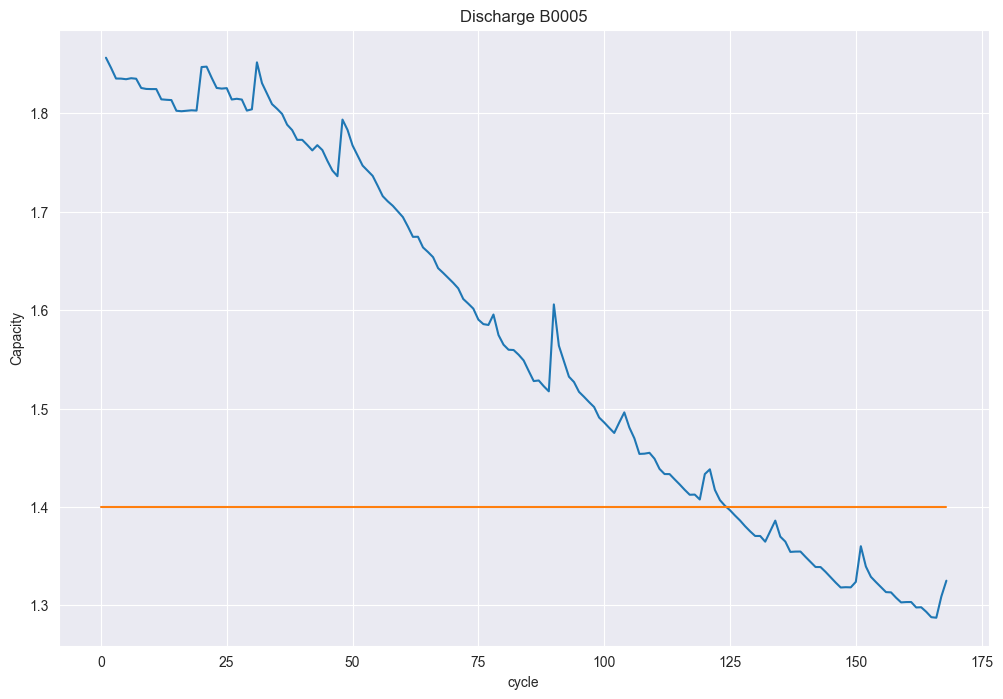

In [4]:
plot_df = capacity.loc[(capacity['cycle']>=1),['cycle','capacity']]
sns.set_style("darkgrid")
plt.figure(figsize=(12, 8))
plt.plot(plot_df['cycle'], plot_df['capacity'])
#Draw threshold
plt.plot([0.,len(capacity)], [1.4, 1.4])
plt.ylabel('Capacity')
# make x-axis ticks legible
adf = plt.gca().get_xaxis().get_major_formatter()
plt.xlabel('cycle')
plt.title('Discharge B0005')

## Train :

In [5]:
attrib=['cycle', 'datetime', 'capacity']
dis_ele = capacity[attrib]
C = dis_ele['capacity'][0]
for i in range(len(dis_ele)):
    dis_ele['SoH']=(dis_ele['capacity'])/C
dis_ele

,cycle,datetime,capacity,SoH
0,1,2008-04-02 15:25:41,1.856487,1.000000
1,2,2008-04-02 19:43:48,1.846327,0.994527
2,3,2008-04-03 00:01:06,1.835349,0.988614
3,4,2008-04-03 04:16:37,1.835263,0.988567
4,5,2008-04-03 08:33:25,1.834646,0.988235
...,...,...,...,...
163,164,2008-05-26 10:44:38,1.293464,0.696726
164,165,2008-05-26 15:30:43,1.288003,0.693785
165,166,2008-05-26 20:21:04,1.287453,0.693488
166,167,2008-05-27 15:52:41,1.309015,0.705103


Text(0.5, 1.0, 'Discharge B0005')

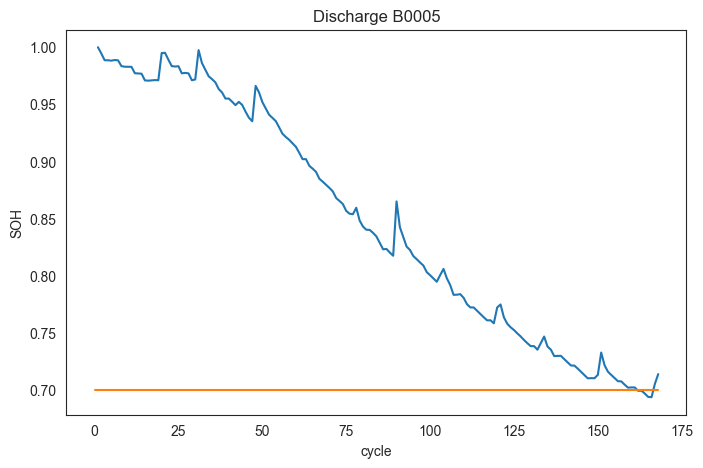

In [6]:
plot_df = dis_ele.loc[(dis_ele['cycle']>=1),['cycle','SoH']]
sns.set_style("white")
plt.figure(figsize=(8, 5))
plt.plot(plot_df['cycle'], plot_df['SoH'])
#Draw threshold
plt.plot([0.,len(capacity)], [0.70, 0.70])
plt.ylabel('SOH')
# make x-axis ticks legible
adf = plt.gca().get_xaxis().get_major_formatter()
plt.xlabel('cycle')
plt.title('Discharge B0005')

In [7]:
from battery_loader import load_data
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# Load data
dataset, capacity_data = load_data('B0005')

# Create SOH - FIXED: use 'data=' not 'dataset='
C = dataset['capacity'][0]
soh = []
for i in range(len(dataset)):
    soh.append((dataset['capacity'][i] / C))
soh = pd.DataFrame(data=soh, columns=['SoH'])

# Extract features
attribs = ['capacity', 'voltage_measured', 'current_measured',
           'temperature_measured', 'current_load', 'voltage_load', 'time']

# FIXED: Use .values to get numpy array directly
train_dataset = dataset[attribs].values

# Apply MinMaxScaler
sc = MinMaxScaler(feature_range=(0, 1))
train_dataset_scaled = sc.fit_transform(train_dataset)

print(train_dataset_scaled.shape)
print(soh.shape)


Total data in dataset:  168
[1, 24.0, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.8564874208181574, 4.191491807505295, -0.0049015892074626, 24.330033885570543, -0.0006, 0.0, 0.0]
(50285, 7)
(50285, 1)


In [8]:
model = Sequential()
model.add(Dense(8, activation='relu', input_dim=train_dataset.shape[1]))
model.add(Dense(8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dropout(rate=0.25))
model.add(Dense(1))
model.summary()
model.compile(optimizer=Adam(beta_1=0.9, beta_2=0.999, epsilon=1e-08), loss='mean_absolute_error')

C:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 8)                   │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 217 (868.00 B)

 Trainable params: 217 (868.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.fit(x=train_dataset, y=soh.to_numpy(), batch_size=25, epochs=70)

Epoch 1/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 8.6595 
Epoch 2/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0869
Epoch 3/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0869
Epoch 4/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0869
Epoch 5/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0869
Epoch 6/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0869
Epoch 7/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.0869
Epoch 8/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0869
Epoch 9/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0869
Epoch 10/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0869
Epoch 11/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0869
Epoch 12/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.0869
Epoch 13/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.0869
Epoch 14/70
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0869
Epoch 15/70
2012/2012 ━━

In [10]:
dataset_val, capacity_val = load_data('B0007')
attrib=['cycle', 'datetime', 'capacity']
dis_ele = capacity_val[attrib]
C = dis_ele['capacity'][0]
for i in range(len(dis_ele)):
    dis_ele['SoH']=(dis_ele['capacity']) / C
print(dataset_val.head(5))
print(dis_ele.head(5))


Total data in dataset:  168
[1, 24.0, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.89105229539079, 4.199359521791473, -0.001865891883368, 23.93704394613529, -0.0004, 0.0, 0.0]
   cycle  ambient_temperature            datetime  capacity  voltage_measured  \
0      1                 24.0 2008-04-02 15:25:41  1.891052          4.199360   
1      1                 24.0 2008-04-02 15:25:41  1.891052          4.199497   
2      1                 24.0 2008-04-02 15:25:41  1.891052          3.985606   
3      1                 24.0 2008-04-02 15:25:41  1.891052          3.963247   
4      1                 24.0 2008-04-02 15:25:41  1.891052          3.946647   

   current_measured  temperature_measured  current_load  voltage_load    time  
0         -0.001866             23.937044       -0.0004         0.000   0.000  
1         -0.002139             23.924074       -0.0004         4.215  16.781  
2         -1.988778             24.004257       -2.0000         3.003  35.703  
3         -1.9925

In [11]:
attrib=['capacity', 'voltage_measured', 'current_measured',
        'temperature_measured', 'current_load', 'voltage_load', 'time']
soh_pred = model.predict(sc.fit_transform(dataset_val[attrib]))
print(soh_pred.shape)

C = dataset_val['capacity'][0]
soh = []
for i in range(len(dataset_val)):
  soh.append(dataset_val['capacity'][i] / C)
new_soh = dataset_val.loc[(dataset_val['cycle'] >= 1), ['cycle']]
new_soh['SoH'] =  soh
new_soh['NewSoH'] = soh_pred
new_soh = new_soh.groupby(['cycle']).mean().reset_index()
print(new_soh.head(10))
rms = np.sqrt(mean_squared_error(new_soh['SoH'], new_soh['NewSoH']))
print('Root Mean Square Error: ', rms)

1572/1572 ━━━━━━━━━━━━━━━━━━━━ 1s 608us/step
(50285, 1)
   cycle       SoH    NewSoH
0      1  1.000000  0.811465
1      2  0.994492  0.812221
2      3  0.994506  0.812932
3      4  0.994563  0.813199
4      5  0.993865  0.812878
5      6  0.994526  0.810729
6      7  0.994121  0.811264
7      8  0.994953  0.813873
8      9  0.988704  0.814519
9     10  0.988895  0.814320
Root Mean Square Error:  0.12232632088535277


In [12]:
new_soh

,cycle,SoH,NewSoH
0,1,1.000000,0.811465
1,2,0.994492,0.812221
2,3,0.994506,0.812932
3,4,0.994563,0.813199
4,5,0.993865,0.812878
...,...,...,...
163,164,0.743592,0.757421
164,165,0.743679,0.758661
165,166,0.740569,0.757800
166,167,0.751849,0.766558


Text(0.5, 1.0, 'Discharge B0007')

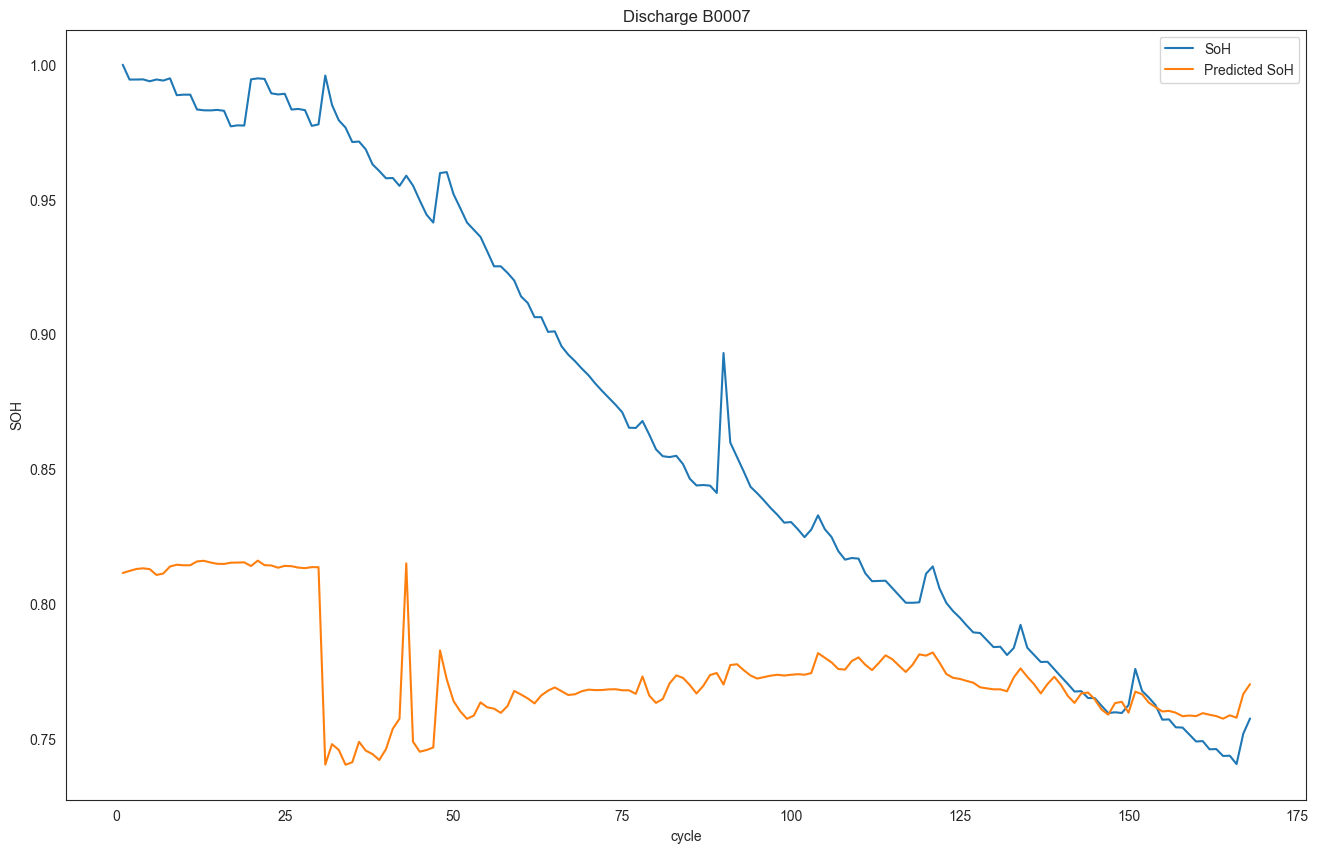

In [13]:
plot_df = new_soh.loc[(new_soh['cycle']>=1),['cycle','SoH', 'NewSoH']]
sns.set_style("white")
plt.figure(figsize=(16, 10))
plt.plot(plot_df['cycle'], plot_df['SoH'], label='SoH')
plt.plot(plot_df['cycle'], plot_df['NewSoH'], label='Predicted SoH')
#Draw threshold
#plt.plot([0.,len(capacity)], [0.70, 0.70], label='Threshold')
plt.ylabel('SOH')
# make x-axis ticks legible
adf = plt.gca().get_xaxis().get_major_formatter()
plt.xlabel('cycle')
plt.legend()
plt.title('Discharge B0007')

# LSTM

In [14]:
from keras.models import Sequential
from keras.layers import LSTM, Dense


In [15]:
train_dataset_lstm = train_dataset.reshape((train_dataset.shape[0], 1, train_dataset.shape[1]))
# Print the current shape of train_dataset
print("Original train_dataset shape:", train_dataset.shape)


# Print the new shape after reshaping
print("Reshaped train_dataset shape:", train_dataset_lstm.shape)

Original train_dataset shape: (50285, 7)
Reshaped train_dataset shape: (50285, 1, 7)


In [16]:
from keras.callbacks import EarlyStopping
from keras.regularizers import l2
model_lstm = Sequential()
model_lstm.add(LSTM(100, activation='relu', input_shape=(train_dataset_lstm.shape[1], train_dataset_lstm.shape[2]), kernel_regularizer=l2(0.001)))
model_lstm.add(Dropout(0.5))  # Increased Dropout rate
model_lstm.add(Dense(1, kernel_regularizer=l2(0.001)))
model_lstm.compile(optimizer='adam', loss='mean_absolute_error')

model_lstm.summary()


C:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100)                 │          43,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,301 (169.14 KB)

 Trainable params: 43,301 (169.14 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from sklearn.model_selection import train_test_split
train_dataset_lstm = np.array(train_dataset_lstm)
soh = np.array(soh)

X_train, X_val, y_train, y_val = train_test_split(train_dataset_lstm, soh, test_size=0.2, random_state=42)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


# Train the model
history = model_lstm.fit(x=X_train, y=y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, verbose=1, callbacks=[early_stopping])

# To access the history
print(history.history)

Epoch 1/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.9910 - val_loss: 0.0688
Epoch 2/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0729 - val_loss: 0.0700
Epoch 3/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0705 - val_loss: 0.0704
Epoch 4/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0705 - val_loss: 0.0707
Epoch 5/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0706 - val_loss: 0.0707
Epoch 6/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0705 - val_loss: 0.0705
Epoch 7/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0704 - val_loss: 0.0703
Epoch 8/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0703 - val_loss: 0.0703
Epoch 9/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0702 - val_loss: 0.0702
Epoch 10/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0702 - val_loss: 0.0703
Epoch 11/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0702 - val_loss: 0.0702
{'loss': [1.991045594215393, 0

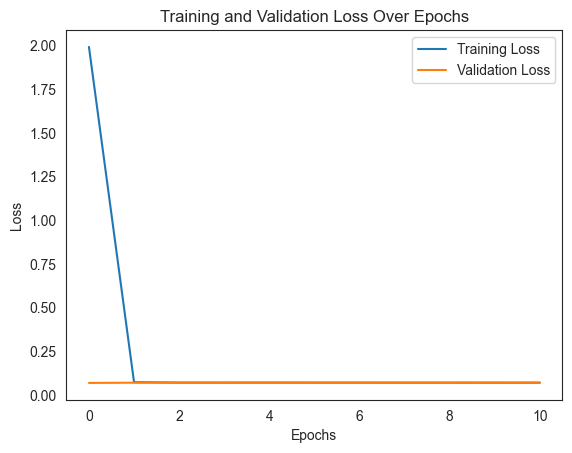

In [18]:
import matplotlib.pyplot as plt

# Plotting the training and validation loss

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [19]:
dataset_val, capacity_val = load_data('B0007')
attrib=['cycle', 'datetime', 'capacity']
dis_ele = capacity_val[attrib]
C = dis_ele['capacity'][0]
for i in range(len(dis_ele)):
    dis_ele['SoH']=(dis_ele['capacity']) / C
print(dataset_val.head(5))
print(dis_ele.head(5))

Total data in dataset:  168
[1, 24.0, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.89105229539079, 4.199359521791473, -0.001865891883368, 23.93704394613529, -0.0004, 0.0, 0.0]
   cycle  ambient_temperature            datetime  capacity  voltage_measured  \
0      1                 24.0 2008-04-02 15:25:41  1.891052          4.199360   
1      1                 24.0 2008-04-02 15:25:41  1.891052          4.199497   
2      1                 24.0 2008-04-02 15:25:41  1.891052          3.985606   
3      1                 24.0 2008-04-02 15:25:41  1.891052          3.963247   
4      1                 24.0 2008-04-02 15:25:41  1.891052          3.946647   

   current_measured  temperature_measured  current_load  voltage_load    time  
0         -0.001866             23.937044       -0.0004         0.000   0.000  
1         -0.002139             23.924074       -0.0004         4.215  16.781  
2         -1.988778             24.004257       -2.0000         3.003  35.703  
3         -1.9925

In [20]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Assuming `attrib` contains the relevant features for the model
attrib = ['capacity', 'voltage_measured', 'current_measured',
          'temperature_measured', 'current_load', 'voltage_load', 'time']

# Ensure dataset_val is available and properly formatted
sc = StandardScaler()
scaled_data = sc.fit_transform(dataset_val[attrib])

# Reshape the data for LSTM (samples, timesteps, features)
# Assuming timesteps=1 if not using a sequence of data points for prediction
scaled_data_lstm = scaled_data.reshape((scaled_data.shape[0], 1, scaled_data.shape[1]))

# Make predictions with the LSTM model
soh_pred = model_lstm.predict(scaled_data_lstm)
print(soh_pred.shape)

# Calculate actual SoH values
C = dataset_val['capacity'].iloc[0]
soh = dataset_val['capacity'] / C

# Prepare a new DataFrame to store the actual and predicted SoH
new_soh_lstm = dataset_val.loc[(dataset_val['cycle'] >= 1), ['cycle']]
new_soh_lstm['SoH'] = soh.values
new_soh_lstm['NewSoH'] = soh_pred.flatten()  # Flatten predicted SoH to 1D array

# Group by cycle and calculate the mean for each cycle
new_soh_lstm = new_soh_lstm.groupby(['cycle']).mean().reset_index()
print(new_soh_lstm)

# Calculate RMSE
rms = np.sqrt(mean_squared_error(new_soh_lstm['SoH'], new_soh_lstm['NewSoH']))
print('Root Mean Square Error: ', rms)


1572/1572 ━━━━━━━━━━━━━━━━━━━━ 2s 902us/step
(50285, 1)
     cycle       SoH    NewSoH
0        1  1.000000  0.801485
1        2  0.994492  0.801222
2        3  0.994506  0.801526
3        4  0.994563  0.801771
4        5  0.993865  0.801654
..     ...       ...       ...
163    164  0.743592  0.773295
164    165  0.743679  0.773292
165    166  0.740569  0.773372
166    167  0.751849  0.773395
167    168  0.757491  0.773397

[168 rows x 3 columns]
Root Mean Square Error:  0.11930062899802243


Text(0.5, 1.0, 'Discharge B0007')

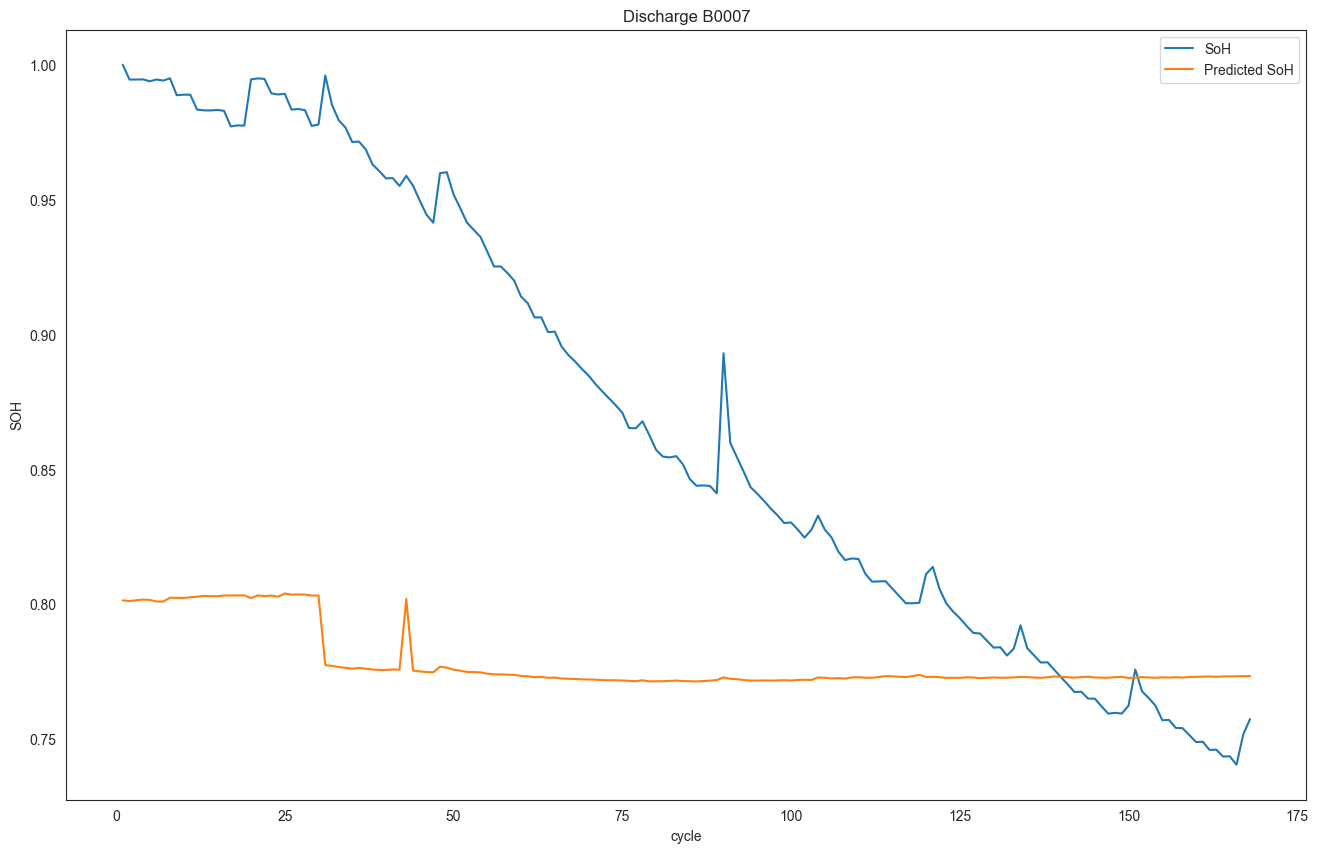

In [21]:
plot_df1 = new_soh_lstm.loc[(new_soh_lstm['cycle']>=1),['cycle','SoH', 'NewSoH']]
sns.set_style("white")
plt.figure(figsize=(16, 10))
plt.plot(plot_df1['cycle'], plot_df1['SoH'], label='SoH')
plt.plot(plot_df1['cycle'], plot_df1['NewSoH'], label='Predicted SoH')
#Draw threshold
#plt.plot([0.,len(capacity)], [0.70, 0.70], label='Threshold')
plt.ylabel('SOH')
# make x-axis ticks legible
adf = plt.gca().get_xaxis().get_major_formatter()
plt.xlabel('cycle')
plt.legend()
plt.title('Discharge B0007')

# CNN


In [22]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import train_test_split
from keras.layers import BatchNormalization


# Reshape the data to fit Conv1D input requirements
train_dataset_reshaped = train_dataset.reshape((train_dataset.shape[0], train_dataset.shape[1], 1))

model_cnn = Sequential()
model_cnn.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(train_dataset_reshaped.shape[1], 1), padding='same'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Dropout(0.5))

model_cnn.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Dropout(0.5))

model_cnn.add(Flatten())
model_cnn.add(Dense(50, activation='relu', kernel_regularizer=l2(0.001)))
model_cnn.add(Dense(1))

# Compile the model
model_cnn.compile(optimizer='adam', loss='mean_squared_error')

# Assuming `soh` is the target variable
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(train_dataset_reshaped, soh, test_size=0.2, random_state=42)

# Fit the model

# Define the EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Fit the model with early stopping
history = model_cnn.fit(X_train, y_train, 
                    validation_data=(X_val, y_val), 
                    epochs=50, 
                    batch_size=32, 
                    callbacks=[early_stopping], 
                    verbose=1)

# To access the history
print(history.history)

Epoch 1/50


C:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1258/1258 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1683 - val_loss: 0.0574
Epoch 2/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0472 - val_loss: 0.0318
Epoch 3/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0249 - val_loss: 0.0150
Epoch 4/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0118 - val_loss: 0.0055
Epoch 5/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0054 - val_loss: 0.0018
Epoch 6/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0034 - val_loss: 0.0021
Epoch 7/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 8/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0024 - val_loss: 0.0010
Epoch 9/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0020 - val_loss: 0.0012
Epoch 10/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0016 - val_loss: 0.0010
Epoch 11/50
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0013 - val_loss: 7.6589e-04
Epoch 12/50
1258/1258 ━━━━━━━━━━━━━━━

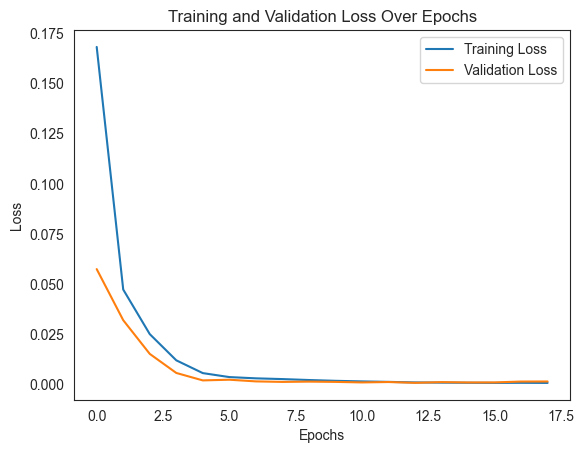

In [23]:
import matplotlib.pyplot as plt

# Plotting the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [24]:
dataset_val, capacity_val = load_data('B0007')
attrib=['cycle', 'datetime', 'capacity']
dis_ele = capacity_val[attrib]
C = dis_ele['capacity'][0]
for i in range(len(dis_ele)):
    dis_ele['SoH']=(dis_ele['capacity']) / C
print(dataset_val.head(5))
print(dis_ele.head(5))

Total data in dataset:  168
[1, 24.0, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.89105229539079, 4.199359521791473, -0.001865891883368, 23.93704394613529, -0.0004, 0.0, 0.0]
   cycle  ambient_temperature            datetime  capacity  voltage_measured  \
0      1                 24.0 2008-04-02 15:25:41  1.891052          4.199360   
1      1                 24.0 2008-04-02 15:25:41  1.891052          4.199497   
2      1                 24.0 2008-04-02 15:25:41  1.891052          3.985606   
3      1                 24.0 2008-04-02 15:25:41  1.891052          3.963247   
4      1                 24.0 2008-04-02 15:25:41  1.891052          3.946647   

   current_measured  temperature_measured  current_load  voltage_load    time  
0         -0.001866             23.937044       -0.0004         0.000   0.000  
1         -0.002139             23.924074       -0.0004         4.215  16.781  
2         -1.988778             24.004257       -2.0000         3.003  35.703  
3         -1.9925

In [25]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Assuming `attrib` contains the relevant features for the model
attrib = ['capacity', 'voltage_measured', 'current_measured',
          'temperature_measured', 'current_load', 'voltage_load', 'time']


# Reshape the data for CNN (samples, timesteps, features)
# CNN typically expects 3D data: (samples, timesteps, features)
# If using Conv1D, we treat timesteps as a sequence length, set timesteps to 1 for single-step predictions
scaled_data_cnn = scaled_data.reshape((scaled_data.shape[0], scaled_data.shape[1], 1))

# Make predictions with the CNN model
soh_pred_cnn = model_cnn.predict(scaled_data_cnn)
print(soh_pred_cnn.shape)

# Calculate actual SoH values
C = dataset_val['capacity'].iloc[0]
soh = dataset_val['capacity'] / C

# Prepare a new DataFrame to store the actual and predicted SoH
new_soh_cnn = dataset_val.loc[(dataset_val['cycle'] >= 1), ['cycle']]
new_soh_cnn['SoH'] = soh.values
new_soh_cnn['NewSoH'] = soh_pred_cnn.flatten()  # Flatten predicted SoH to 1D array

# Group by cycle and calculate the mean for each cycle
new_soh_cnn = new_soh_cnn.groupby(['cycle']).mean().reset_index()
print(new_soh_cnn)

# Calculate RMSE
rms_cnn = np.sqrt(mean_squared_error(new_soh_cnn['SoH'], new_soh_cnn['NewSoH']))
print('Root Mean Square Error: ', rms_cnn)


1572/1572 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
(50285, 1)
     cycle       SoH    NewSoH
0        1  1.000000  0.721201
1        2  0.994492  0.721982
2        3  0.994506  0.722156
3        4  0.994563  0.721438
4        5  0.993865  0.720570
..     ...       ...       ...
163    164  0.743592  0.532830
164    165  0.743679  0.532829
165    166  0.740569  0.532806
166    167  0.751849  0.532956
167    168  0.757491  0.533052

[168 rows x 3 columns]
Root Mean Square Error:  0.27245792257680707


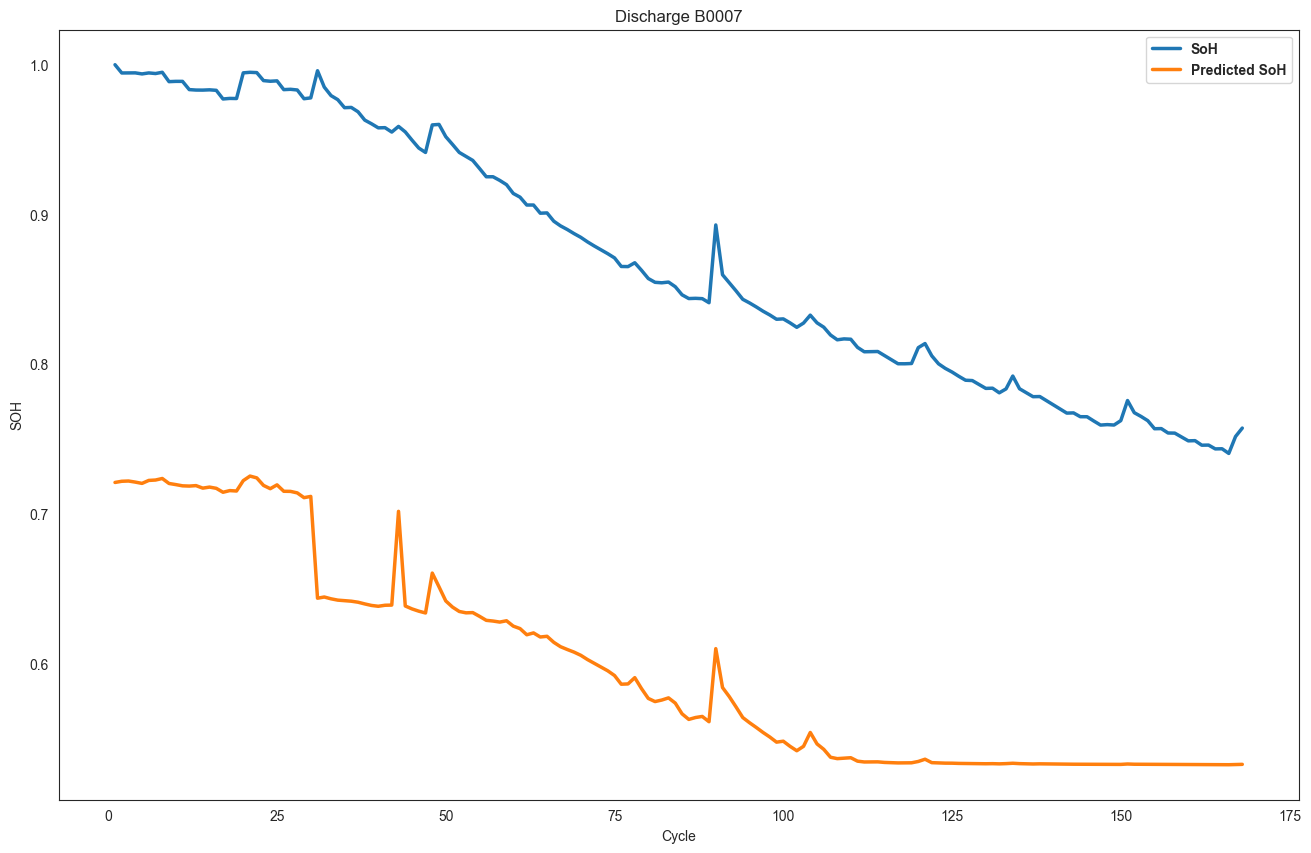

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the data you want to plot
plot_df = new_soh_cnn.loc[(new_soh_cnn['cycle'] >= 1), ['cycle', 'SoH', 'NewSoH']]

# Set the style of the plot
sns.set_style("white")

# Create the figure with a specified size
plt.figure(figsize=(16, 10))

# Plot the actual and predicted SoH with increased line thickness
plt.plot(plot_df['cycle'], plot_df['SoH'], label='SoH', linewidth=2.5)
plt.plot(plot_df['cycle'], plot_df['NewSoH'], label='Predicted SoH', linewidth=2.5)

# Add labels and titles
plt.ylabel('SOH')
plt.xlabel('Cycle')
plt.title('Discharge B0007')

# Customize the legend: bold font and larger size
plt.legend(fontsize=14, loc='best', title_fontsize='13', title='Legend', fancybox=True, shadow=True)
plt.legend(prop={'weight': 'bold'})

# Save the plot as a PDF file
plt.savefig('pics/soh_discharge_plot_cnn.pdf', format='pdf')


# Display the plot
plt.show()


[0]	validation_0-rmse:0.07269	validation_1-rmse:0.07281
[1]	validation_0-rmse:0.06543	validation_1-rmse:0.06554
[2]	validation_0-rmse:0.05890	validation_1-rmse:0.05900
[3]	validation_0-rmse:0.05302	validation_1-rmse:0.05311
[4]	validation_0-rmse:0.04773	validation_1-rmse:0.04782
[5]	validation_0-rmse:0.04297	validation_1-rmse:0.04304
[6]	validation_0-rmse:0.03869	validation_1-rmse:0.03875
[7]	validation_0-rmse:0.03483	validation_1-rmse:0.03489
[8]	validation_0-rmse:0.03136	validation_1-rmse:0.03141
[9]	validation_0-rmse:0.02823	validation_1-rmse:0.02828
[10]	validation_0-rmse:0.02542	validation_1-rmse:0.02546
[11]	validation_0-rmse:0.02289	validation_1-rmse:0.02293
[12]	validation_0-rmse:0.02061	validation_1-rmse:0.02065
[13]	validation_0-rmse:0.01856	validation_1-rmse:0.01860
[14]	validation_0-rmse:0.01672	validation_1-rmse:0.01675
[15]	validation_0-rmse:0.01506	validation_1-rmse:0.01509
[16]	validation_0-rmse:0.01357	validation_1-rmse:0.01359
[17]	validation_0-rmse:0.01223	validation

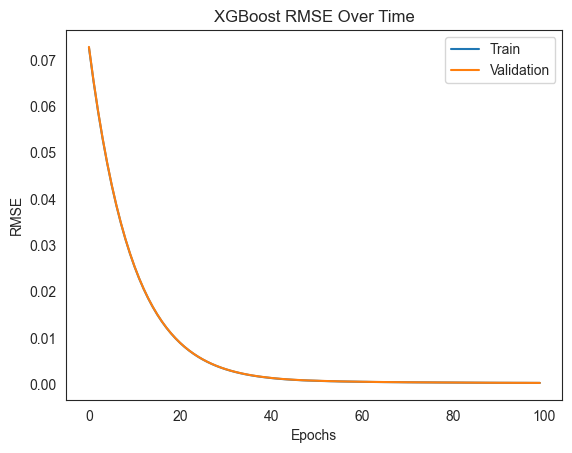

In [27]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Split the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(train_dataset, soh, test_size=0.2, random_state=42)

# Create the XGBRegressor model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric='rmse')

# Define the eval set
eval_set = [(X_train, y_train), (X_val, y_val)]

# Fit the model with early stopping
model.fit(X_train, y_train, 
          eval_set=eval_set, 
          verbose=True)

# Retrieve performance metrics
results = model.evals_result()

# Plotting the RMSE for training and validation
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

plt.plot(x_axis, results['validation_0']['rmse'], label='Train')
plt.plot(x_axis, results['validation_1']['rmse'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('XGBoost RMSE Over Time')
plt.legend()
plt.show()


In [28]:
dataset_val, capacity_val = load_data('B0007')
attrib=['cycle', 'datetime', 'capacity']
dis_ele = capacity_val[attrib]
C = dis_ele['capacity'][0]
for i in range(len(dis_ele)):
    dis_ele['SoH']=(dis_ele['capacity']) / C
print(dataset_val.head(5))
print(dis_ele.head(5))

Total data in dataset:  168
[1, 24.0, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.89105229539079, 4.199359521791473, -0.001865891883368, 23.93704394613529, -0.0004, 0.0, 0.0]
   cycle  ambient_temperature            datetime  capacity  voltage_measured  \
0      1                 24.0 2008-04-02 15:25:41  1.891052          4.199360   
1      1                 24.0 2008-04-02 15:25:41  1.891052          4.199497   
2      1                 24.0 2008-04-02 15:25:41  1.891052          3.985606   
3      1                 24.0 2008-04-02 15:25:41  1.891052          3.963247   
4      1                 24.0 2008-04-02 15:25:41  1.891052          3.946647   

   current_measured  temperature_measured  current_load  voltage_load    time  
0         -0.001866             23.937044       -0.0004         0.000   0.000  
1         -0.002139             23.924074       -0.0004         4.215  16.781  
2         -1.988778             24.004257       -2.0000         3.003  35.703  
3         -1.9925

In [29]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Assuming `attrib` contains the relevant features for the model
attrib = ['capacity', 'voltage_measured', 'current_measured',
          'temperature_measured', 'current_load', 'voltage_load', 'time']


# Reshape the data for CNN (samples, timesteps, features)
# CNN typically expects 3D data: (samples, timesteps, features)
# If using Conv1D, we treat timesteps as a sequence length, set timesteps to 1 for single-step predictions
scaled_data_cnn = scaled_data.reshape((scaled_data.shape[0], scaled_data.shape[1], 1))

# Make predictions with the CNN model
soh_pred_cnn = model_cnn.predict(scaled_data_cnn)
print(soh_pred_cnn.shape)

# Calculate actual SoH values
C = dataset_val['capacity'].iloc[0]
soh = dataset_val['capacity'] / C

# Prepare a new DataFrame to store the actual and predicted SoH
new_soh_cnn = dataset_val.loc[(dataset_val['cycle'] >= 1), ['cycle']]
new_soh_cnn['SoH'] = soh.values
new_soh_cnn['NewSoH'] = soh_pred_cnn.flatten()  # Flatten predicted SoH to 1D array

# Group by cycle and calculate the mean for each cycle
new_soh_cnn = new_soh_cnn.groupby(['cycle']).mean().reset_index()
print(new_soh_cnn)

# Calculate RMSE
rms_cnn = np.sqrt(mean_squared_error(new_soh_cnn['SoH'], new_soh_cnn['NewSoH']))
print('Root Mean Square Error: ', rms_cnn)


1572/1572 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
(50285, 1)
     cycle       SoH    NewSoH
0        1  1.000000  0.721201
1        2  0.994492  0.721982
2        3  0.994506  0.722156
3        4  0.994563  0.721438
4        5  0.993865  0.720570
..     ...       ...       ...
163    164  0.743592  0.532830
164    165  0.743679  0.532829
165    166  0.740569  0.532806
166    167  0.751849  0.532956
167    168  0.757491  0.533052

[168 rows x 3 columns]
Root Mean Square Error:  0.27245792257680707
